Text(0, 0.5, 'Diffusion time t')

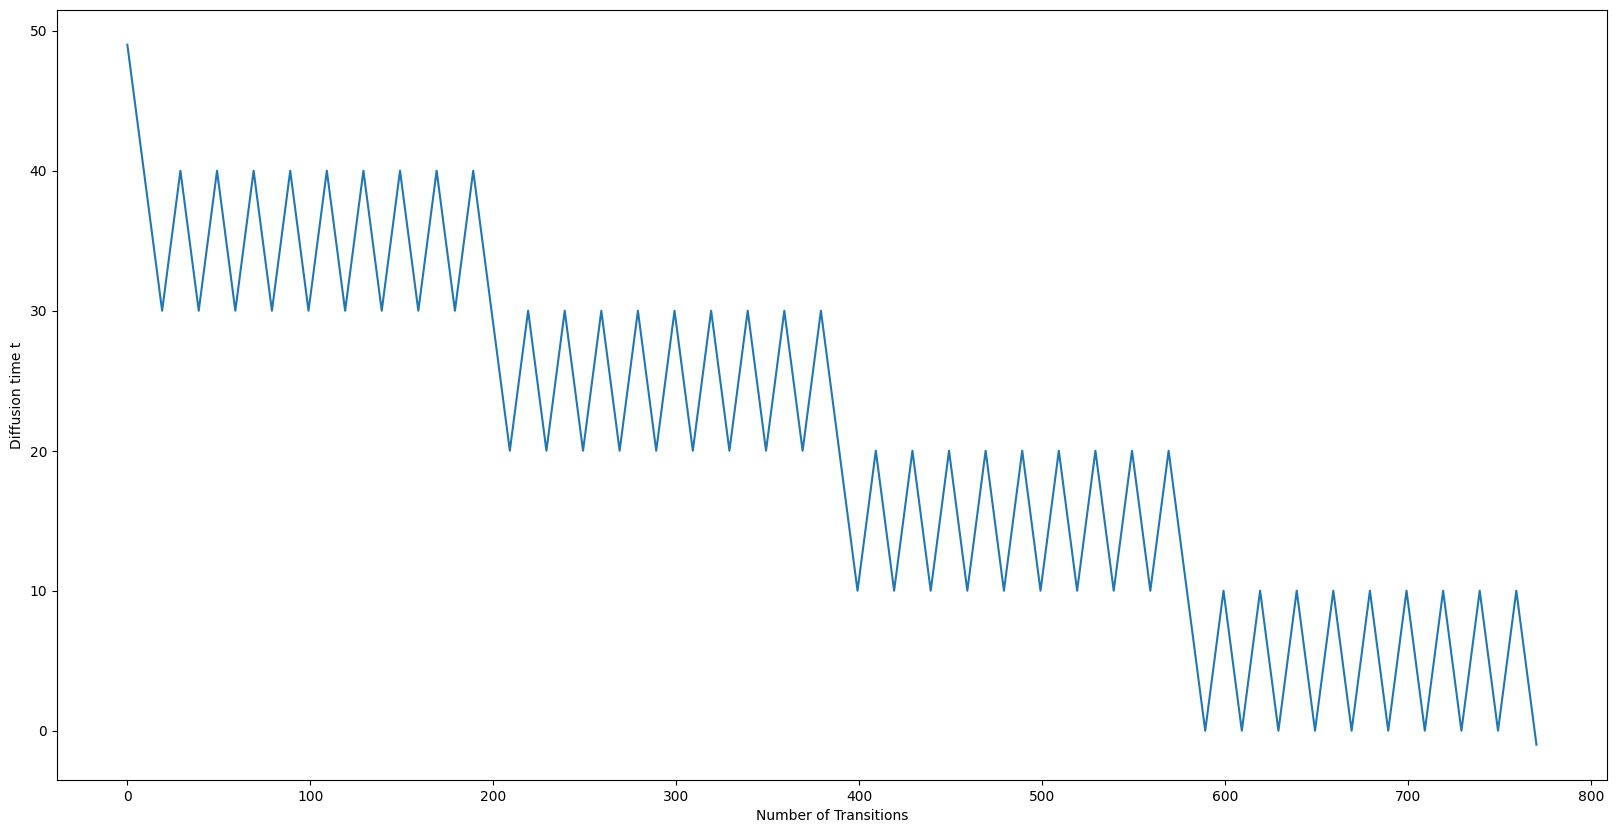

In [15]:
import matplotlib.pyplot as plt

t_T = 50
jump_len = 10
jump_n_sample = 10

jumps = {}
for j in range(0, t_T - jump_len, jump_len):
    jumps[j] = jump_n_sample - 1
t = t_T
ts = []

while t >= 1:
    t = t-1
    ts.append(t)
    
    if jumps.get(t, 0) > 0:
        jumps[t] = jumps[t] - 1
        for _ in range(jump_len):
            t = t + 1
            ts.append(t)
ts.append(-1)

# tsをx軸index,y軸値にしてプロット
# 画像サイズを大きく指定する
plt.figure(figsize=(20, 10))
plt.plot(ts)
plt.xlabel('Number of Transitions')
plt.ylabel('Diffusion time t')

Text(0, 0.5, 'Diffusion time t')

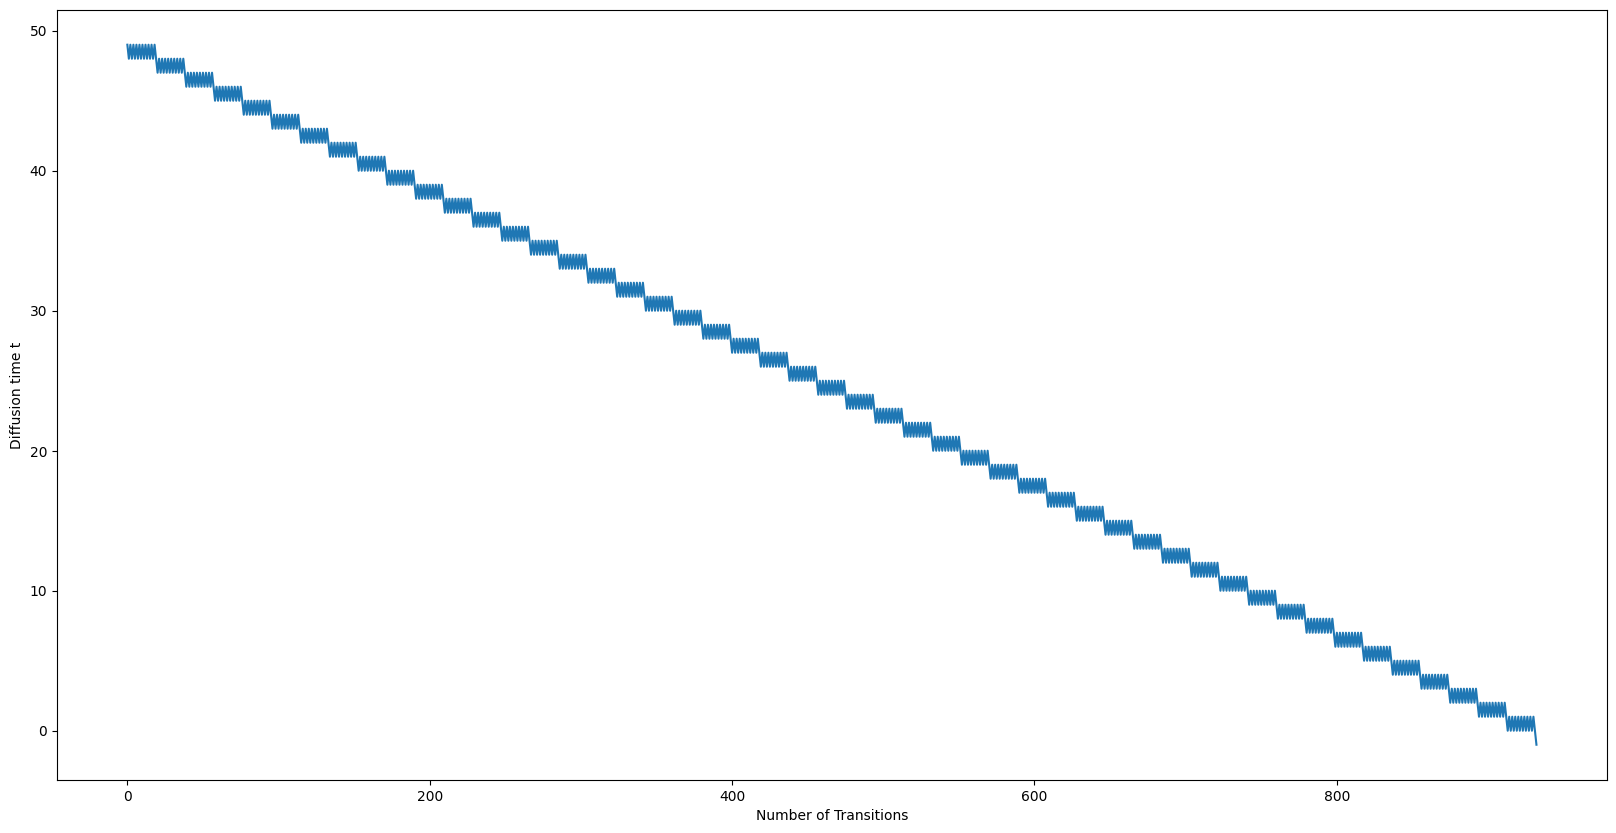

In [19]:
import matplotlib.pyplot as plt

t_T = 50
jump_len = 1
jump_n_sample = 10

jumps = {}
for j in range(0, t_T - jump_len, jump_len):
    jumps[j] = jump_n_sample - 1
t = t_T
ts = []

while t >= 1:
    t = t - 1
    ts.append(t)

    if jumps.get(t, 0) > 0:
        jumps[t] = jumps[t] - 1
        for _ in range(jump_len):
            t = t + 1
            ts.append(t)
ts.append(-1)

# tsをx軸index,y軸値にしてプロット
# 画像サイズを大きく指定する
plt.figure(figsize=(20, 10))
plt.plot(ts)
plt.xlabel("Number of Transitions")
plt.ylabel("Diffusion time t")

Text(0, 0.5, 'Diffusion time t')

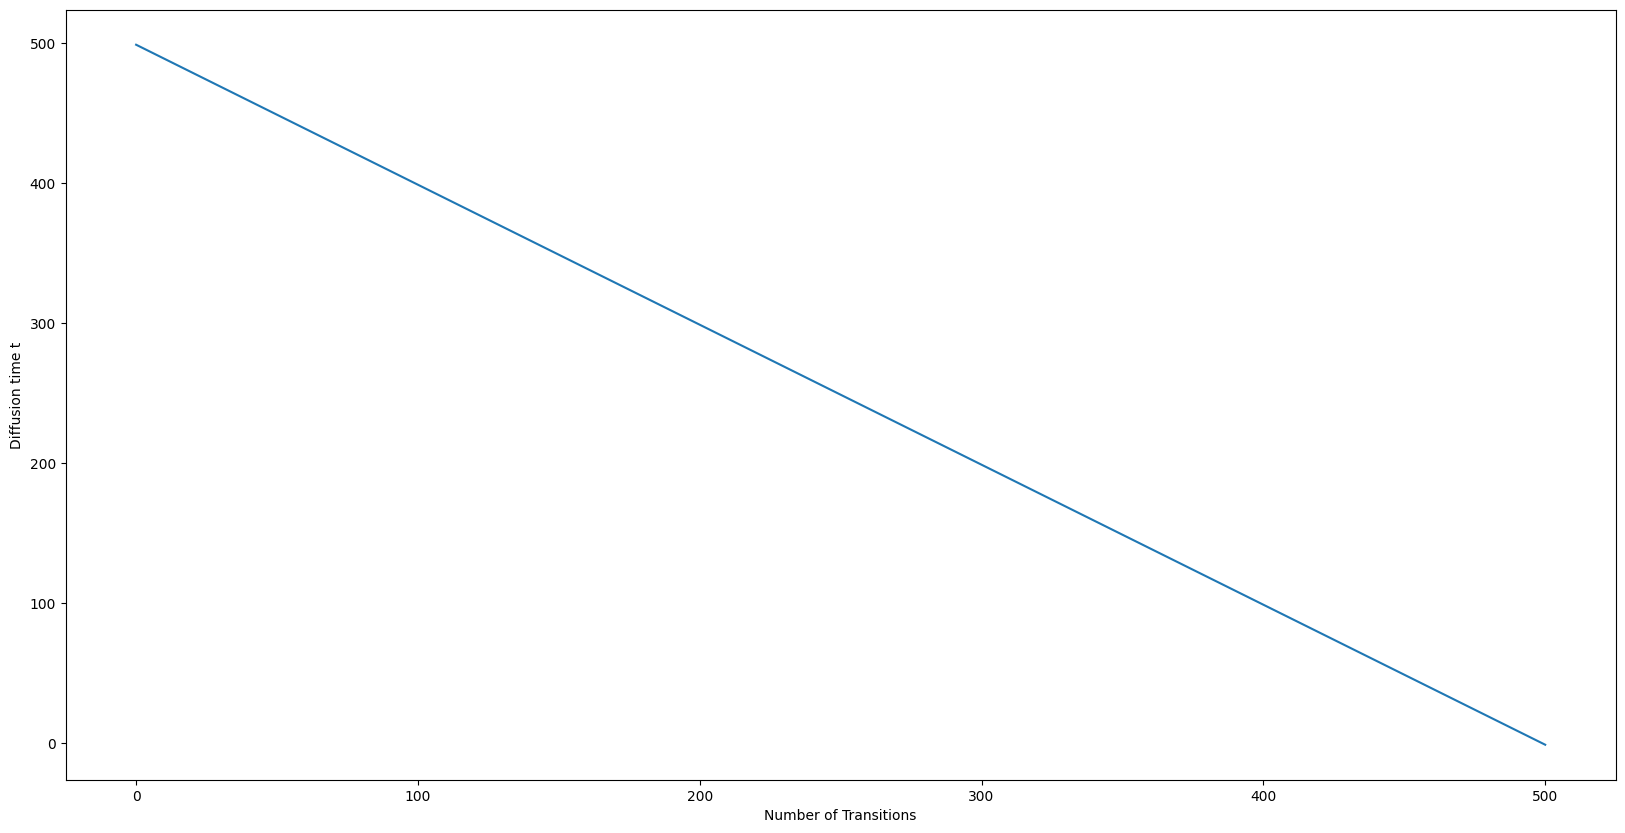

In [62]:
import matplotlib.pyplot as plt

t_T = 500
jump_len = 1
jump_n_sample = 1

jumps = {}
for j in range(0, t_T - jump_len, jump_len):
    jumps[j] = jump_n_sample - 1
t = t_T
ts = []

while t >= 1:
    t = t - 1
    ts.append(t)

    if jumps.get(t, 0) > 0:
        jumps[t] = jumps[t] - 1
        for _ in range(jump_len):
            t = t + 1
            ts.append(t)
ts.append(-1)

# tsをx軸index,y軸値にしてプロット
# 画像サイズを大きく指定する
plt.figure(figsize=(20, 10))
plt.plot(ts)
plt.xlabel("Number of Transitions")
plt.ylabel("Diffusion time t")

In [63]:
print(len(ts))
print(ts)

501
[499, 498, 497, 496, 495, 494, 493, 492, 491, 490, 489, 488, 487, 486, 485, 484, 483, 482, 481, 480, 479, 478, 477, 476, 475, 474, 473, 472, 471, 470, 469, 468, 467, 466, 465, 464, 463, 462, 461, 460, 459, 458, 457, 456, 455, 454, 453, 452, 451, 450, 449, 448, 447, 446, 445, 444, 443, 442, 441, 440, 439, 438, 437, 436, 435, 434, 433, 432, 431, 430, 429, 428, 427, 426, 425, 424, 423, 422, 421, 420, 419, 418, 417, 416, 415, 414, 413, 412, 411, 410, 409, 408, 407, 406, 405, 404, 403, 402, 401, 400, 399, 398, 397, 396, 395, 394, 393, 392, 391, 390, 389, 388, 387, 386, 385, 384, 383, 382, 381, 380, 379, 378, 377, 376, 375, 374, 373, 372, 371, 370, 369, 368, 367, 366, 365, 364, 363, 362, 361, 360, 359, 358, 357, 356, 355, 354, 353, 352, 351, 350, 349, 348, 347, 346, 345, 344, 343, 342, 341, 340, 339, 338, 337, 336, 335, 334, 333, 332, 331, 330, 329, 328, 327, 326, 325, 324, 323, 322, 321, 320, 319, 318, 317, 316, 315, 314, 313, 312, 311, 310, 309, 308, 307, 306, 305, 304, 303, 302, 301, 

In [9]:
import torch
alphas = torch.Tensor([1,2,3,4,5,6,7,8,9,10])
alpha_bars = torch.Tensor([11,12,13,14,15,16,17,18,19,20])

In [ ]:
import tqdm

class Diffuser:
    def __init__(self):
        pass

# --- Diffuser に RePaint メソッドを追加 ---
class RePaintDiffuser(Diffuser):

    def __init__(self, *args, num_resampling=3, jump_length=10, **kwargs):
        super().__init__(*args, **kwargs)

        assert jump_length >= 1 and num_resampling >= 1
        self.num_resampling = num_resampling  # R: 同じtでのサンプリング回数（R=1だとJによらず通常の生成）
        self.jump_length = jump_length  # J: tを進める長さ（通常の生成ではJ=1）

    def add_noise_onestep(self, x, t):
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all(), "t must be in [1, T]"
        t_idx = t - 1
        beta = self.betas[t_idx].view(-1, 1, 1)
        noise = torch.randn_like(x, device=self.device)
        x_t = torch.sqrt(1 - beta) * x + torch.sqrt(beta) * noise
        return x_t

    def schedule_timesteps(num_timesteps: int, jump_length:int, num_resampling:int):

        ### RePaint論文内の実装 ###
        jumps = {}
        for j in range(0, num_timesteps - jump_length, jump_length):
            jumps[j] = num_resampling - 1
        t = num_timesteps
        ts = []

        while t >= 1:
            t = t-1
            ts.append(t)

            if jumps.get(t, 0) > 0:
                jumps[t] = jumps[t] - 1
                for _ in range(jump_length):
                    t = t + 1
                    ts.append(t)
        ts.append(-1)
        #########################

        # 全てのtを1ずつ増加させる
        ts  = [t+1 for t in ts]

        return ts

    def repaint(self, model, x_orig, mask, c):
        """
        RePaint アルゴリズムによる欠損値補完
        x_orig: [B,2,L] の既知領域データ
        mask:    [B,L] の bool Tensor (True=known, False=to inpaint)
        c:       [B,1] の正規化済み Cl 条件
        返り値:  [B,2,L] の inpainted サンプル
        """

        B, C, L = x_orig.shape
        device = x_orig.device
        # 初期ノイズ
        x = torch.randn_like(x_orig, device=device)
        mask = mask.unsqueeze(1).expand(-1, C, -1)

        ts = self.schedule_timesteps(self.num_timesteps, self.jump_length, self.num_resampling)

        for i, t in tqdm(enumerate(ts), desc="RePaint", total=len(ts)):
            # 現在のtをテンソル化
            t_tensor = torch.full((B,), t, dtype=torch.long, device=device)

            # 次のtを見て、tを進めるかor戻すかを決定
            if i < len(ts) - 1:
                next_t = ts[i + 1]
                if next_t < t:
                    # backward jump 
                    x_known, _ = self.add_noise(x_0=x_orig, t=t_tensor-1)
                    x_unknown, _ = self.denoise(model=model, x=x, t=t_tensor, c=c)
                    x = torch.where(mask, x_known, x_unknown)
                elif next_t > t:
                    # forward jump
                    x = self.add_noise_onestep(x, t_tensor)
                else:
                    pass
            else:
                # 最後のtはbackward jump
                x_known, _ = self.add_noise(x_0=x_orig, t=t-1)
                x_unknown, _ = self.denoise(model=model, x=x, t=t_tensor, c=c)
                x = torch.where(mask, x_known, x_unknown)
        
        return x

In [55]:
import numpy as np

# maskはshape=(248,)で、True=既知(known)、False=欠損(unknown)

# 末尾を欠損しているパターン
mask = np.array([False] * 10 + [True] * 228 + [False] * 10)
# 先頭を欠損しているパターン
mask = np.array([True] * 114 + [False] * 20 + [True] * 114)
# 中央上部を欠損しているパターン
mask = np.array([True] * 124 + [True] * 52 + [False] * 20 + [True] * 52)

assert mask.shape == (248,)